# Compile Master Baseline Table




In [1]:
# ============================================================
# 1. IMPORTS + CONFIG
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/SoftCom Project/Dataset"

RESULT_FOLDERS = {
    "resnet50":        os.path.join(DATASET_ROOT, "Baseline_Results/ResNet50"),
    "efficientnet_b0":  os.path.join(DATASET_ROOT, "Baseline_Results/EfficientNet-B0"),
    "dinov2":          os.path.join(DATASET_ROOT, "Baseline_Results/DINOv2"),
    "convnext_tiny":   os.path.join(DATASET_ROOT, "Baseline_Results/ConvNeXt-Tiny"),
}

MASTER_OUTPUT_FOLDER = os.path.join(DATASET_ROOT, "Master_Baseline_Results")
os.makedirs(MASTER_OUTPUT_FOLDER, exist_ok=True)


Mounted at /content/drive


In [2]:
# ============================================================
# 2. LOAD TEST-SPLIT RESULTS
# ============================================================

RESULT_FILENAMES = {
    "resnet50": "resnet50_baseline_results.csv",
    "efficientnet_b0": "efficientnet_b0_baseline_results.csv",
    "dinov2": "dinov2_baseline_results.csv",
    "convnext_tiny": "convnext_tiny_baseline_results.csv",
}

all_results = []
for backbone, folder in RESULT_FOLDERS.items():
    path = os.path.join(folder, RESULT_FILENAMES[backbone])
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["backbone"] = backbone
        all_results.append(df)
        print(f"Loaded {len(df)} rows from {backbone}")
    else:
        print(f"⚠️  Not found: {path} -- run that backbone's notebook first, or check the path.")

master_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()


Loaded 10 rows from resnet50
Loaded 10 rows from efficientnet_b0
Loaded 10 rows from dinov2
Loaded 10 rows from convnext_tiny


In [3]:
# ============================================================
# 3. SANITY CHECK --
# ============================================================

if "efficientnet_b0" not in master_df["backbone"].unique():
    print("⚠️  efficientnet_b0 rows not found in master_df -- check that "
          "efficientnet_b0_baseline.ipynb has been run and its results CSV saved.")
else:
    print("EfficientNet-B0 rows loaded:")
    display(master_df[master_df["backbone"] == "efficientnet_b0"])

print("\nMaster table rows:", len(master_df))


EfficientNet-B0 rows loaded:


,task,method,accuracy,macro_f1,backbone
10,indoor,frozen_efficientnet_b0_logreg,0.916667,0.850000,efficientnet_b0
11,indoor,finetuned_efficientnet_b0_two_stage,0.875000,0.794872,efficientnet_b0
12,indoor,frozen_efficientnet_b0_linear_svm,0.833333,0.619048,efficientnet_b0
13,indoor,frozen_efficientnet_b0_knn,0.791667,0.581882,efficientnet_b0
14,indoor,naive_majority,0.791667,0.441860,efficientnet_b0
15,wall_type,finetuned_efficientnet_b0_two_stage,0.666667,0.685758,efficientnet_b0
16,wall_type,frozen_efficientnet_b0_logreg,0.583333,0.480317,efficientnet_b0
17,wall_type,frozen_efficientnet_b0_linear_svm,0.541667,0.411905,efficientnet_b0
18,wall_type,frozen_efficientnet_b0_knn,0.333333,0.263835,efficientnet_b0
19,wall_type,naive_majority,0.458333,0.125714,efficientnet_b0



Master table rows: 40


## Merge in GroupKFold cross-validated estimates




In [4]:
# ============================================================
# 4. LOAD + MERGE GROUPKFOLD RESULTS
# ============================================================

GROUPKFOLD_FILENAMES = {
    "resnet50": "resnet50_groupkfold_results.csv",
    "efficientnet_b0": "efficientnet_b0_groupkfold_results.csv",
    "dinov2": "dinov2_groupkfold_results.csv",
    "convnext_tiny": "convnext_tiny_groupkfold_results.csv",
}

cv_results = []
for backbone, folder in RESULT_FOLDERS.items():
    path = os.path.join(folder, GROUPKFOLD_FILENAMES[backbone])
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["backbone"] = backbone
        cv_results.append(df)
        print(f"Loaded GroupKFold results for {backbone}")
    else:
        print(f"⚠️  No GroupKFold results yet for {backbone} at {path} -- run that cell first.")

cv_df = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()

if not cv_df.empty:
    cv_df["groupkfold_macro_f1"] = cv_df.apply(
        lambda r: f"{r['mean_macro_f1']:.3f} ± {r['std_macro_f1']:.3f}", axis=1
    )
    master_df = master_df.merge(
        cv_df[["task", "backbone", "groupkfold_macro_f1"]],
        on=["task", "backbone"], how="left",
    )
else:
    master_df["groupkfold_macro_f1"] = None


Loaded GroupKFold results for resnet50
Loaded GroupKFold results for efficientnet_b0
Loaded GroupKFold results for dinov2
Loaded GroupKFold results for convnext_tiny


## Master table

In [5]:
# ============================================================
# 5. FINAL MASTER TABLE
# ============================================================

master_df = master_df.sort_values(["task", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
master_df.to_csv(os.path.join(MASTER_OUTPUT_FOLDER, "master_baseline_table.csv"), index=False)
display(master_df)


,task,method,accuracy,macro_f1,backbone,groupkfold_macro_f1
0,indoor,frozen_convnext_tiny_logreg,0.958333,0.931624,convnext_tiny,0.789 ± 0.076
1,indoor,frozen_dinov2_linear_head,0.916667,0.888889,dinov2,0.883 ± 0.049
2,indoor,frozen_dinov2_logreg,0.916667,0.873684,dinov2,0.883 ± 0.049
3,indoor,frozen_dinov2_linear_svm,0.916667,0.873684,dinov2,0.883 ± 0.049
4,indoor,frozen_efficientnet_b0_logreg,0.916667,0.850000,efficientnet_b0,0.773 ± 0.066
5,indoor,frozen_convnext_tiny_linear_svm,0.916667,0.850000,convnext_tiny,0.789 ± 0.076
6,indoor,finetuned_convnext_tiny,0.916667,0.850000,convnext_tiny,0.789 ± 0.076
7,indoor,frozen_resnet50_logreg,0.875000,0.794872,resnet50,0.838 ± 0.045
8,indoor,frozen_resnet50_linear_svm,0.875000,0.794872,resnet50,0.838 ± 0.045
9,indoor,finetuned_efficientnet_b0_two_stage,0.875000,0.794872,efficientnet_b0,0.773 ± 0.066


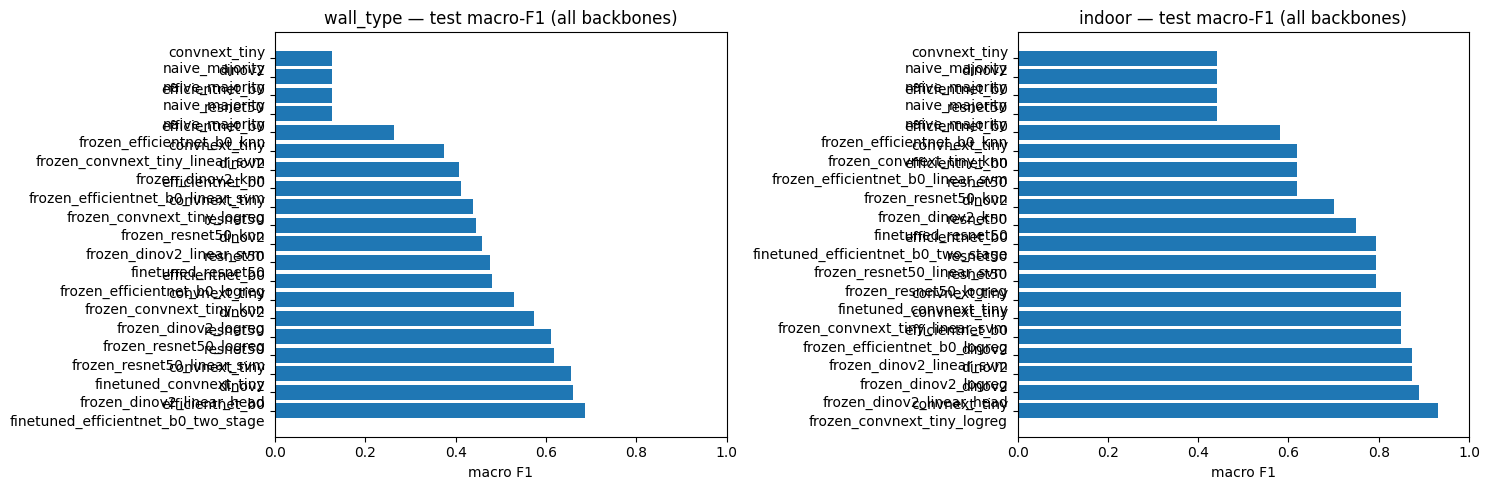

In [6]:
# ============================================================
# 6. COMPARISON CHART
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, task in zip(axes, ["wall_type", "indoor"]):
    sub = master_df[master_df["task"] == task].copy()
    sub["label"] = sub["backbone"] + "\n" + sub["method"]
    ax.barh(sub["label"], sub["macro_f1"])
    ax.set_title(f"{task} — test macro-F1 (all backbones)")
    ax.set_xlabel("macro F1")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(MASTER_OUTPUT_FOLDER, "master_comparison_chart.png"), dpi=150)
plt.show()


## Export a LaTeX table for the paper

In [7]:
# ============================================================
# 7. LATEX TABLE EXPORT
# ============================================================

latex_columns = ["task", "backbone", "method", "accuracy", "macro_f1", "groupkfold_macro_f1"]
latex_df = master_df[[c for c in latex_columns if c in master_df.columns]].copy()
latex_df.columns = [c.replace("_", " ").title() for c in latex_df.columns]

latex_str = latex_df.to_latex(
    index=False, float_format="%.3f", na_rep="--",
    caption="Baseline classification results across backbones.",
    label="tab:baseline_results",
)

latex_path = os.path.join(MASTER_OUTPUT_FOLDER, "master_baseline_table.tex")
with open(latex_path, "w") as f:
    f.write(latex_str)

print("LaTeX table saved to:", latex_path)
print()
print(latex_str)


LaTeX table saved to: /content/drive/MyDrive/SoftCom Project/Dataset/Master_Baseline_Results/master_baseline_table.tex

\begin{table}
\caption{Baseline classification results across backbones.}
\label{tab:baseline_results}
\begin{tabular}{lllrrl}
\toprule
Task & Backbone & Method & Accuracy & Macro F1 & Groupkfold Macro F1 \\
\midrule
indoor & convnext_tiny & frozen_convnext_tiny_logreg & 0.958 & 0.932 & 0.789 ± 0.076 \\
indoor & dinov2 & frozen_dinov2_linear_head & 0.917 & 0.889 & 0.883 ± 0.049 \\
indoor & dinov2 & frozen_dinov2_logreg & 0.917 & 0.874 & 0.883 ± 0.049 \\
indoor & dinov2 & frozen_dinov2_linear_svm & 0.917 & 0.874 & 0.883 ± 0.049 \\
indoor & efficientnet_b0 & frozen_efficientnet_b0_logreg & 0.917 & 0.850 & 0.773 ± 0.066 \\
indoor & convnext_tiny & frozen_convnext_tiny_linear_svm & 0.917 & 0.850 & 0.789 ± 0.076 \\
indoor & convnext_tiny & finetuned_convnext_tiny & 0.917 & 0.850 & 0.789 ± 0.076 \\
indoor & resnet50 & frozen_resnet50_logreg & 0.875 & 0.795 & 0.838 ± 0.045 \